# 02 — Validación, modelos y robustez

Comparación fuera de muestra sobre desarrollo mediante ventanas
expansivas, selección interna temporal y purga de etiquetas no
publicadas. Las métricas se agregan sobre 46 orígenes de pronóstico.

In [1]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: C:\Users\litoa\OneDrive\Documents\GitHub\ml_finance_carenas\Morosidad_bancaria_arenas


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv(ROOT / "reports" / "tables" / "model_comparison_development.csv")
overall = metrics.loc[metrics["fold_id"].astype(str) == "all"].copy()
overall = overall.sort_values("mae")
overall[["model", "n", "mae", "rmse", "directional_accuracy"]]

,model,n,mae,rmse,directional_accuracy
39,zero_change,46,0.433693,0.565590,0.000000
33,elastic_net,46,0.506537,0.635077,0.413043
38,xgboost,46,0.536918,0.676250,0.413043
34,last_observed_change,46,0.553815,0.712182,0.673913
36,random_forest,46,0.583562,0.734495,0.521739
35,moving_average_change_12,46,0.618102,0.726954,0.543478
32,autoregressive_ols,46,0.627994,0.795439,0.608696
37,seasonal_naive_change_12,46,0.729797,0.822160,0.434783


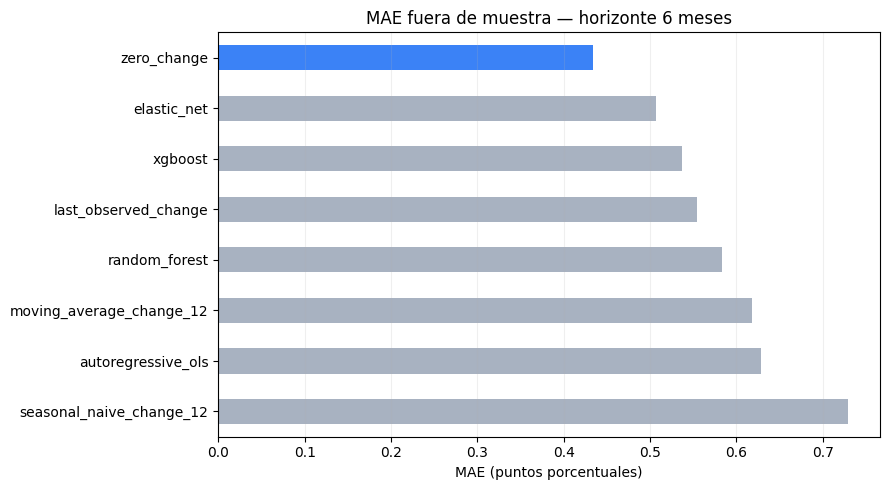

In [3]:
colors = ["#3b82f6" if model == "zero_change" else "#a8b2c1" for model in overall["model"]]
axis = overall.plot.barh(x="model", y="mae", color=colors, figsize=(9, 5), legend=False)
axis.invert_yaxis()
axis.set(title="MAE fuera de muestra — horizonte 6 meses", xlabel="MAE (puntos porcentuales)", ylabel="")
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## Estabilidad frente al benchmark cambio cero

In [4]:
stability = pd.read_csv(ROOT / "reports" / "tables" / "stability_vs_zero_development.csv")
stability.loc[
    stability["model"].isin(["elastic_net", "random_forest", "xgboost"]),
    ["model", "mae", "mae_improvement_vs_zero_pct", "bootstrap_probability_better_than_zero", "ci_conclusion"],
].sort_values("mae")

,model,mae,mae_improvement_vs_zero_pct,bootstrap_probability_better_than_zero,ci_conclusion
1,elastic_net,0.506537,-16.796343,0.0662,inconclusive
9,xgboost,0.536918,-23.801475,0.0950,inconclusive
7,random_forest,0.583562,-34.556658,0.0982,inconclusive


## Robustez por horizonte

In [5]:
horizons = pd.read_csv(ROOT / "reports" / "tables" / "horizon_robustness_metrics.csv")
horizon_overall = horizons.loc[
    (horizons["fold_id"].astype(str) == "all")
    & (horizons["training_scheme"] == "expanding")
].copy()
horizon_table = horizon_overall.pivot(index="horizon_months", columns="model", values="mae")
horizon_table["elastic_net_improvement_vs_zero_pct"] = (
    (horizon_table["zero_change"] - horizon_table["elastic_net"])
    / horizon_table["zero_change"] * 100
)
horizon_table

model,elastic_net,zero_change,elastic_net_improvement_vs_zero_pct
horizon_months,,,
3,0.286815,0.245852,-16.661751
6,0.506537,0.433693,-16.796343
12,0.642957,0.659556,2.516697


## Drivers del challenger

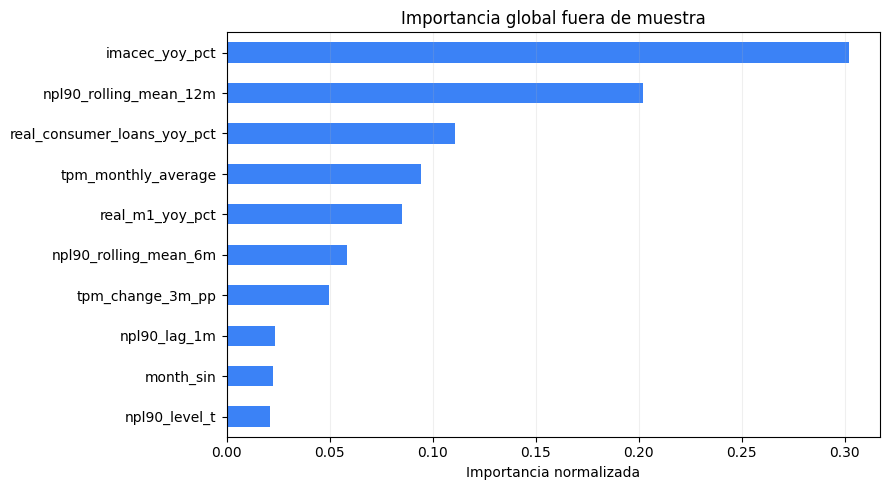

In [6]:
importance = pd.read_csv(ROOT / "reports" / "tables" / "feature_importance_global.csv")
top = importance.loc[
    (importance["fold_id"].astype(str) == "all")
    & (importance["model"] == "elastic_net")
].nsmallest(10, "rank")
axis = top.sort_values("normalized_importance").plot.barh(
    x="feature", y="normalized_importance", figsize=(9, 5), color="#3b82f6", legend=False
)
axis.set(title="Importancia global fuera de muestra", xlabel="Importancia normalizada", ylabel="")
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

**Lectura:** cambio cero mantiene el menor MAE a seis meses.
ElasticNet es el mejor modelo aprendido, pero su mejora es negativa y
la evidencia bootstrap no permite promoverlo. El resultado positivo
de `h=12` permanece como hipótesis descriptiva, no como autorización
para cambiar el campeón.